In [2]:
# Core libraries
import numpy as np
import tensorflow as tf

# Visualization
import matplotlib.pyplot as plt

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [4]:
# load CIFAR-10 dataset
(x_train_T, y_train_T), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

N_train_T = np.shape(x_train_T)[0]
N_train = round(0.8*N_train_T) # 80% for train and 20% for validation
x_train,y_train = x_train_T[0:N_train],y_train_T[0:N_train]
x_val,y_val = x_train_T[N_train:],y_train_T[N_train:]

# Pixels normalization ([0,255] to [0,1])
x_train, x_val, x_test = x_train / 255.0, x_val / 255.0, x_test / 255.0

# One-Hot encoding
y_train_c = to_categorical(y_train, 10)
y_val_c = to_categorical(y_val, 10)
y_test_c = to_categorical(y_test, 10)
print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)

(40000, 32, 32, 3)
(40000, 1)
(10000, 32, 32, 3)
(10000, 1)


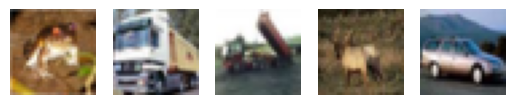

In [5]:
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i],cmap='gray')
    plt.axis('off')
plt.show()

In [7]:
model_basic = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3) ,
    padding='same'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu',padding='same'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [8]:
model_basic.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model_basic.compile(optimizer='adam',loss='categorical_crossentropy',
metrics=['accuracy'])

callback = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [12]:
import time
start_time = time.time()

history = model_basic.fit(x_train, y_train_c, epochs=15, batch_size=32,
validation_data=(x_val, y_val_c), callbacks=[callback])

end_time = time.time()
temps_app = end_time - start_time

model_basic.save_weights('models_weight/model_basic.weights.h5', overwrite=True, max_shard_size=None)

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.4782 - loss: 1.4490 - val_accuracy: 0.5541 - val_loss: 1.2471
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6235 - loss: 1.0697 - val_accuracy: 0.6210 - val_loss: 1.0865
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6756 - loss: 0.9300 - val_accuracy: 0.6636 - val_loss: 0.9712
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7121 - loss: 0.8238 - val_accuracy: 0.6887 - val_loss: 0.9031
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7412 - loss: 0.7388 - val_accuracy: 0.6897 - val_loss: 0.8971
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7696 - loss: 0.6552 - val_accuracy: 0.6920 - val_loss: 0.9180
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7922 - loss: 0.5885 - val_accuracy: 0.6858 - val_loss: 0.9868
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8176 - loss: 0

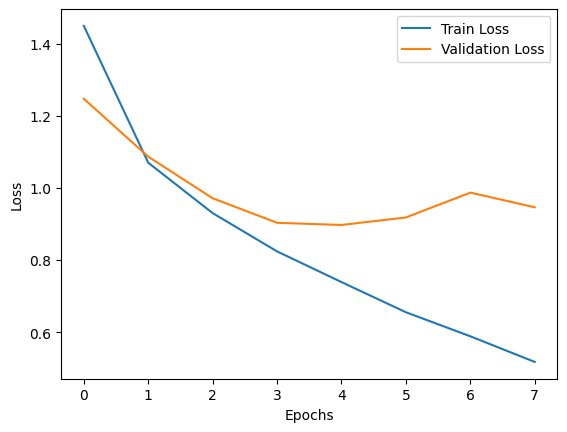

In [13]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [14]:
start_time = time.time()
test_history = model_basic.predict(x_test)
end_time = time.time()
temps_test = end_time - start_time

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [15]:
test_loss, test_acc = model_basic.evaluate(x_test, y_test_c)
print(f"\nTest Accuracy: {test_acc:.4f}, Training Time: {temps_app:.1f} seconds, Test time: {temps_test:.1f} seconds")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6872 - loss: 0.9012

Test Accuracy: 0.6872, Training Time: 87.0 seconds, Test time: 0.8 seconds


In [16]:
model_medium = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3),
    padding='same'),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3),
    padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    Conv2D(64, (3,3), activation='relu',padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.25),
    Dense(10, activation='softmax')
])

In [25]:
model_medium.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,775,360 (6.77 MB)

 Trainable params: 591,658 (2.26 MB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 1,183,318 (4.51 MB)

In [17]:
model_medium.compile(optimizer='adam',loss='categorical_crossentropy',
metrics=['accuracy'])

In [18]:
import time
start_time = time.time()

history = model_medium.fit(x_train, y_train_c, epochs=15, batch_size=32,
validation_data=(x_val, y_val_c), callbacks=[callback])

end_time = time.time()
temps_app = end_time - start_time

model_medium.save_weights('models_weight/model_medium.weights.h5', overwrite=True, max_shard_size=None)

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.4202 - loss: 1.6101 - val_accuracy: 0.5274 - val_loss: 1.3766
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.5802 - loss: 1.1732 - val_accuracy: 0.6270 - val_loss: 1.0457
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.6488 - loss: 1.0041 - val_accuracy: 0.6649 - val_loss: 0.9612


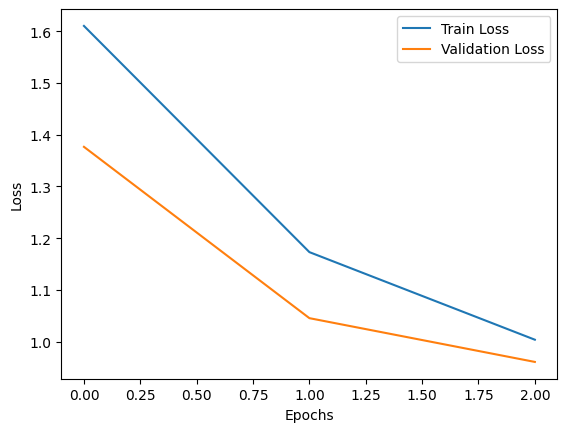

In [19]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [20]:
start_time = time.time()
test_history = model_medium.predict(x_test)
end_time = time.time()
temps_test = end_time - start_time

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [21]:
test_loss, test_acc = model_medium.evaluate(x_test, y_test_c)
print(f"\nTest Accuracy: {test_acc:.4f}, Training Time: {temps_app:.1f} seconds, Test time: {temps_test:.1f} seconds")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5268 - loss: 1.3714

Test Accuracy: 0.5268, Training Time: 123.2 seconds, Test time: 2.3 seconds


In [26]:
model_deep = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3),
    padding='same'),
    Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3),
    padding='same'),
    Conv2D(128, (3,3), activation='relu', input_shape=(32,32,3),
    padding='same'),
    Conv2D(128, (3,3), activation='relu', input_shape=(32,32,3),
    padding='same'),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu', input_shape=(32,32,3),
    padding='same'),
    Conv2D(256, (3,3), activation='relu', input_shape=(32,32,3),
    padding='same'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.25),
    Dense(10, activation='softmax')
])

In [27]:
model_deep.compile(optimizer='adam',loss='categorical_crossentropy',
metrics=['accuracy'])

In [28]:
model_deep.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,978 (12.37 MB)

 Trainable params: 3,243,978 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
import time
start_time = time.time()

history = model_deep.fit(x_train, y_train_c, epochs=15, batch_size=32,
validation_data=(x_val, y_val_c), callbacks=[callback])

end_time = time.time()
temps_app = end_time - start_time

model_deep.save_weights('models_weight/model_deep.weights.h5', overwrite=True, max_shard_size=None)

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 505s 404ms/step - accuracy: 0.3748 - loss: 1.6939 - val_accuracy: 0.5165 - val_loss: 1.3057
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 896s 717ms/step - accuracy: 0.5587 - loss: 1.2312 - val_accuracy: 0.6247 - val_loss: 1.0551
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 478s 383ms/step - accuracy: 0.6436 - loss: 1.0130 - val_accuracy: 0.6833 - val_loss: 0.8934
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 480s 384ms/step - accuracy: 0.6938 - loss: 0.8649 - val_accuracy: 0.7148 - val_loss: 0.8081
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 793s 634ms/step - accuracy: 0.7325 - loss: 0.7587 - val_accuracy: 0.7203 - val_loss: 0.8131
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 438s 351ms/step - accuracy: 0.7657 - loss: 0.6654 - val_accuracy: 0.7157 - val_loss: 0.8173
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 514s 411ms/step - accuracy: 0.7918 - loss: 0.5852 - val_accuracy: 0.7314 - val_loss: 0.8136


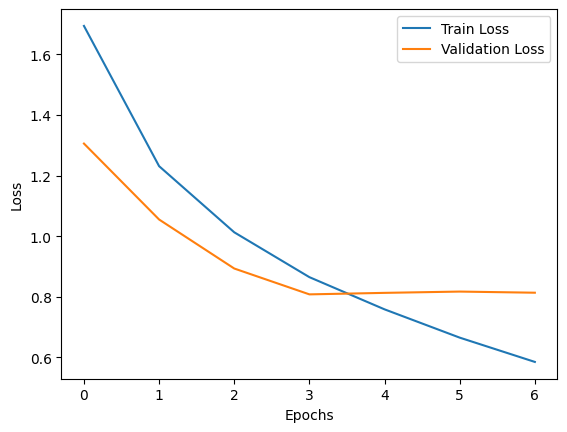

In [30]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [31]:
start_time = time.time()
test_history = model_deep.predict(x_test)
end_time = time.time()
temps_test = end_time - start_time

313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step


In [32]:
test_loss, test_acc = model_deep.evaluate(x_test, y_test_c)
print(f"\nTest Accuracy: {test_acc:.4f}, Training Time: {temps_app:.1f} seconds, Test time: {temps_test:.1f} seconds")

313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.7146 - loss: 0.8151

Test Accuracy: 0.7146, Training Time: 4104.3 seconds, Test time: 30.0 seconds
